<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_5_Support_Vector_Machine_%26_ROC_Curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 5 - 9.6.2 Support Vector Machine & 9.6.3 ROC Curves
###STATS 302 Principle of Machine Learning
###Duke Kunshan University




In [ ]:
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,roc_curve

from mlxtend.plotting import plot_decision_regions

import matplotlib.pyplot as plt
import seaborn as sns

# 9.6.2 Support Vector Machine

## Generating toy dataset

In [ ]:
#setting the seed
X = np.random.normal(size = (200,2))
X[:100,] += 2
X[100:150,] -= 2
y = [0]*150 + [1]*50

data = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})
data.head()

,X1,X2,y
0,2.291682,1.567480,0
1,3.676615,3.436660,0
2,0.845847,4.485205,0
3,1.532420,0.447757,0
4,2.565133,3.725062,0


<Axes: xlabel='X1', ylabel='X2'>

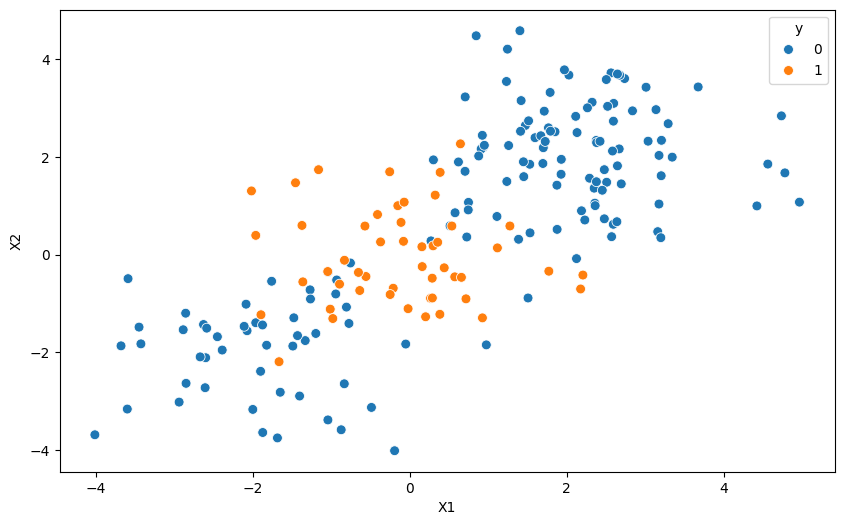

In [ ]:
#plotting the data
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'X1',y = 'X2',hue = 'y',data = data,s = 50)

We can say that there is no possible linearly separation between the two classes

In [ ]:
#splitting the data into train and test
X_train,X_test,y_train,y_test = train_test_split(data.drop('y',axis=1),data['y'],test_size = 0.5,random_state = 1)
print(X_train.shape,X_test.shape)

(100, 2) (100, 2)


## Fitting the model with radical kernal to training data
Gamma is used when we use the radical kernel. If you use linear or polynomial kernel then you do not need gamma only you need C hypermeter.

In [ ]:
svm = SVC(kernel='rbf',gamma = 1,C = 1)
svm.fit(X_train,y_train)

SVC(C=1, gamma=1)

### Plotting the decision boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'X2')

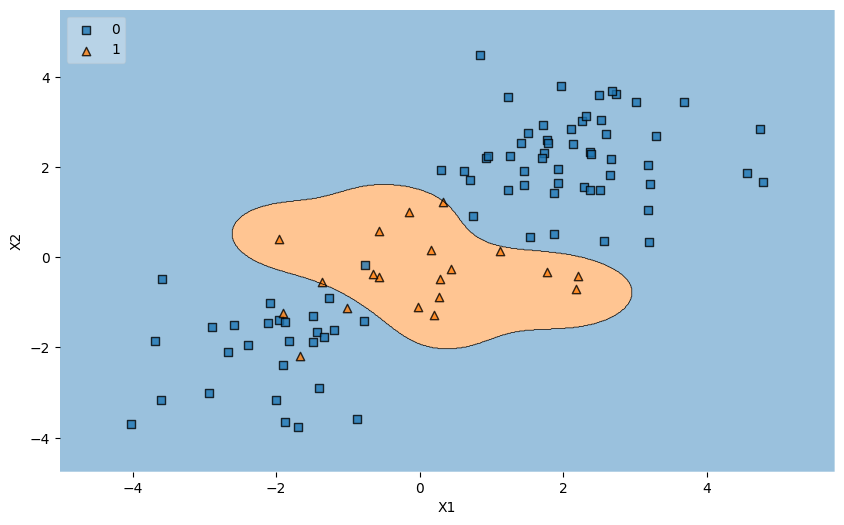

In [ ]:
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(X_train), np.array(y_train), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

In [ ]:
print('Number of Support Vectors are ',svm.support_vectors_.shape[0])
print('Accuracy on training data is ',svm.score(X_train,y_train))

Number of Support Vectors are  50
Accuracy on training data is  0.96


## Choosing a high number of C

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Number of Support Vectors are  21
Accuracy on training data is  1.0


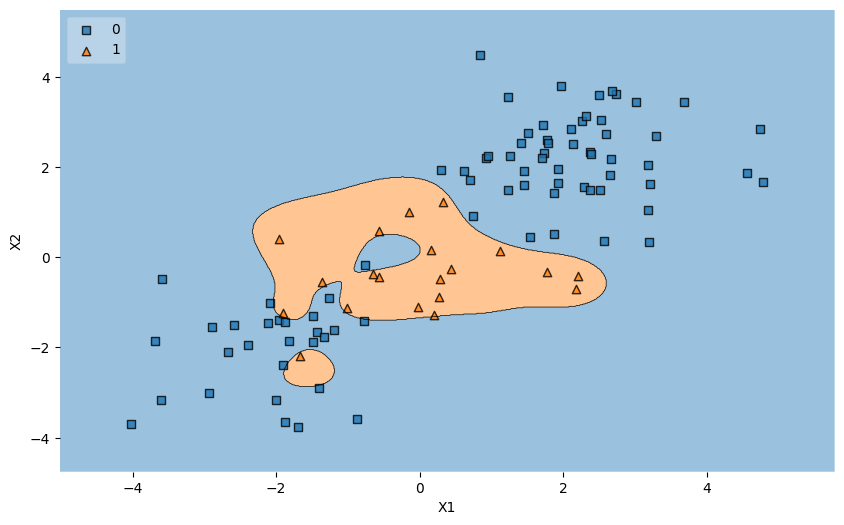

In [ ]:
svm = SVC(kernel='rbf',gamma = 1,C = 10e5)
svm.fit(X_train,y_train)

### Plotting the decision boundary

plt.figure(figsize = (10,6))
plot_decision_regions(np.array(X_train), np.array(y_train), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

print('Number of Support Vectors are ',svm.support_vectors_.shape[0])
print('Accuracy on training data is ',svm.score(X_train,y_train))

## Choosing the optimal value of C and gamma using cross validation

In [ ]:
params_dict = {'C':[0.1,1,10,100,1000],'gamma':[0.5,1,2,3,4]}
search = GridSearchCV(SVC(kernel = 'rbf'),params_dict,cv =10)
search.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [0.5, 1, 2, 3, 4]})

In [ ]:
search.best_params_

{'C': 1, 'gamma': 0.5}

In [ ]:
best_model = search.best_estimator_

## Performance of best_model on test data

In [ ]:
test_preds = best_model.predict(X_test)
print('Test accuracy is ',accuracy_score(y_test,test_preds))
print('Confusion matrix is - ')
print(confusion_matrix(y_test,test_preds))

Test accuracy is  0.85
Confusion matrix is - 
[[60 10]
 [ 5 25]]


# 9.6.3 ROC curves

In [ ]:
def plot_roc(cls,X,y,title):
    probs = cls.predict_proba(X)[:,1]
    fpr, tpr, _ = roc_curve(y,probs)
    auc = roc_auc_score(y,probs)

    plt.figure(figsize = (6,6))
    plt.plot(fpr,tpr,label="auc="+str(auc)[0:4],c = 'r')
    plt.plot([0,1],[0,1],alpha = 0.1,c = 'b')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()


In [ ]:
#because we need probability = True to get probs
best_model.probability = True
best_model.gamma = 0.5
best_model.fit(X_train,y_train)

SVC(C=1, gamma=0.5, probability=True)

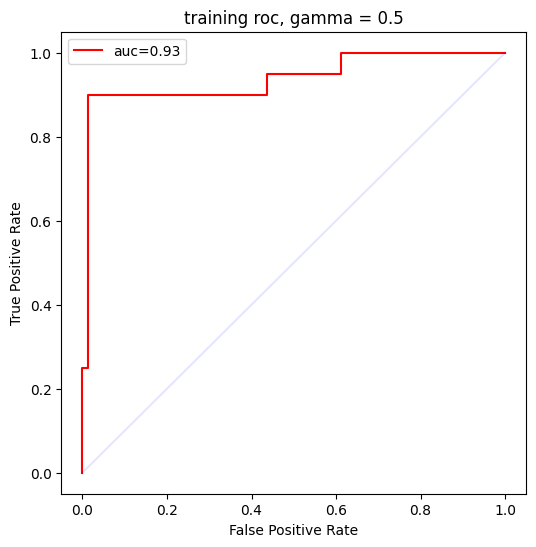

In [ ]:
plot_roc(best_model,X_train,y_train,'training roc, gamma = 0.5')

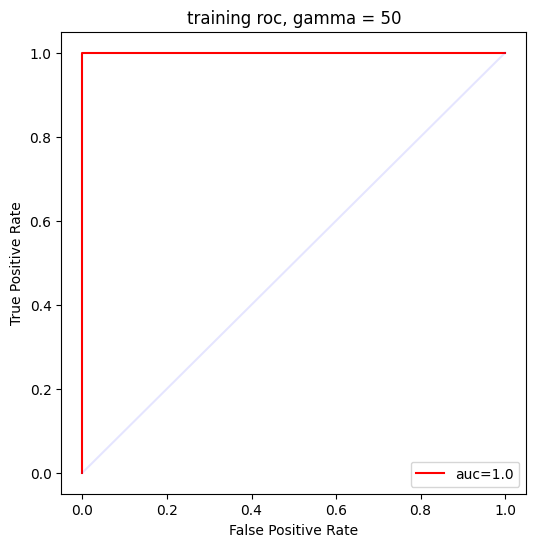

In [ ]:
#roc curve if gamma is high
best_model.probability = True
best_model.gamma = 50
best_model.fit(X_train,y_train)

plot_roc(best_model,X_train,y_train,'training roc, gamma = 50')

woah...but wait, its training roc, not test roc :(

## Plotting the same on test data

In [ ]:
def find_roc_terms(cls,X,y):
    probs = cls.predict_proba(X)[:,1]
    fpr,tpr,_ = roc_curve(y,probs)
    auc = roc_auc_score(y,probs)

    return fpr,tpr,auc

In [ ]:
def plot_roc_test(cls,X_train,y_train,X_test,y_test):
    fpr,tpr,auc = find_roc_terms(cls,X_train,y_train)
    fpr_test,tpr_test,auc_test = find_roc_terms(cls,X_test,y_test)

    fig,(ax1,ax2) = plt.subplots(1,2,figsize = (12,6))
    ax1.plot(fpr,tpr,label="auc="+str(auc)[0:4],c = 'r')
    ax1.plot([0,1],[0,1],alpha = 0.1,c = 'b')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Train Roc')
    ax1.legend()

    ax2.plot(fpr_test,tpr_test,label="auc="+str(auc_test)[0:4],c = 'r')
    ax2.plot([0,1],[0,1],alpha = 0.1,c = 'b')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Test Roc')
    ax2.legend()


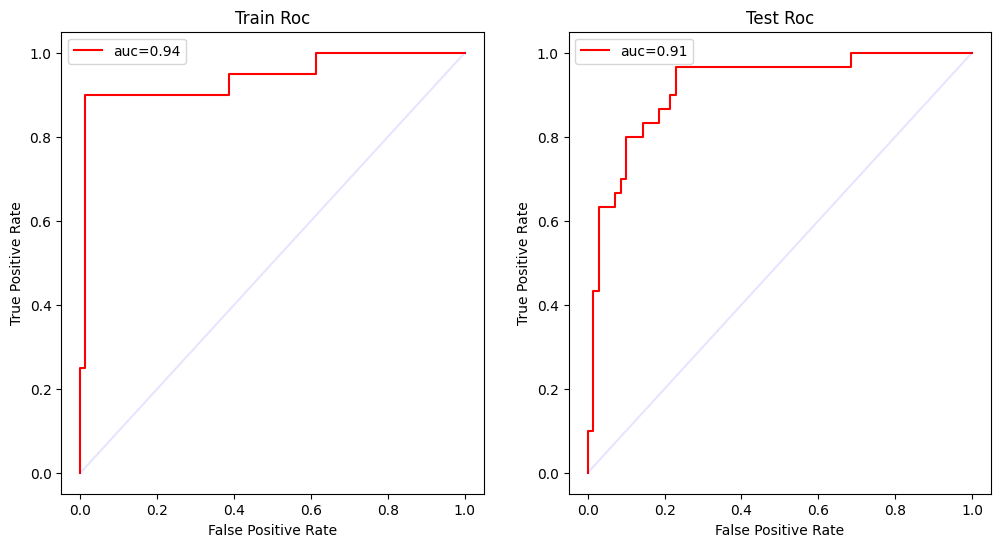

In [ ]:
# for gamma = 0.5
best_model.gamma = 0.5
best_model.fit(X_train,y_train)

plot_roc_test(best_model,X_train,y_train,X_test,y_test)

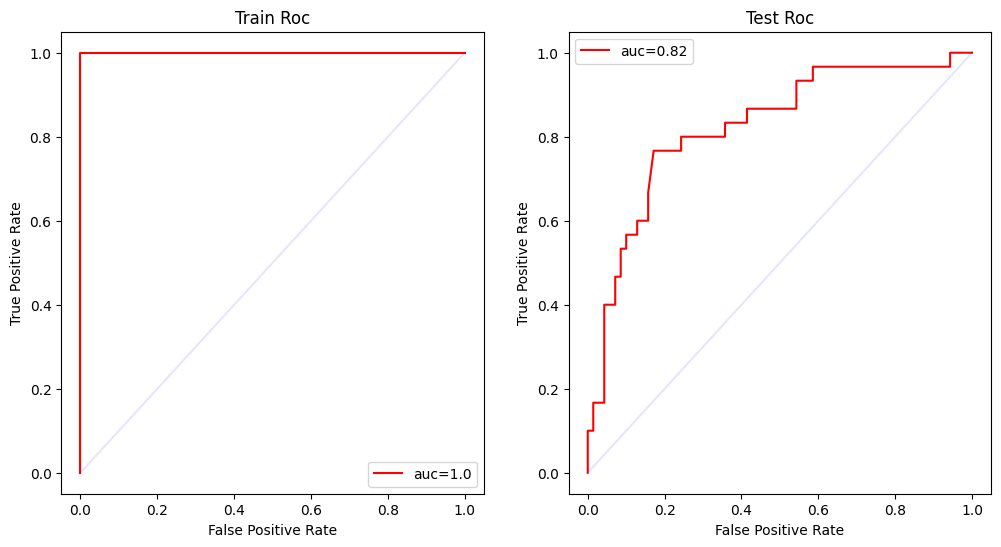

In [ ]:
# for gamma = 50
best_model.gamma = 50
best_model.fit(X_train,y_train)

plot_roc_test(best_model,X_train,y_train,X_test,y_test)